# Wine Dataset EDA 실습

붓꽃(Iris) EDA 실습과 같은 흐름으로 와인(Wine) 데이터를 탐색합니다.

와인 데이터(`wine.csv`, UCI Wine)는 이탈리아 같은 지역에서 재배된 **3개 품종(Wine = 1, 2, 3)** 의 와인 178개를 화학 분석한 결과로, **13개의 연속형 변수**를 가지고 있습니다.

1. 데이터 불러오기
2. 데이터 구조 확인
3. 결측치와 중복 데이터 확인
4. 레이블 종류와 개수 확인
5. 기술통계량 확인
6. 품종별 평균과 표준편차 확인
7. 변수별 분포 확인
8. 품종별 분포 비교
9. Box Plot과 Violin Plot
10. Pair Plot
11. 상관관계 분석
12. 산점도를 이용한 변수 관계 확인
13. IQR 기반 이상치 탐지
14. 품종별 평균 비교 (표준화)
15. 변동계수 확인
16. 변수별 품종 분리도 확인 (ANOVA F값)

## 1. 필요한 라이브러리 불러오기

붓꽃 실습과 동일하게 `pandas`, `numpy`, `matplotlib`, `seaborn`을 사용합니다.
붓꽃 실습처럼 구글 드라이브를 마운트한 뒤 `wine.csv` 파일을 읽습니다. 파일 위치는 자신의 환경에 맞춰 변경합니다.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


sns.set_theme(style="whitegrid")

## 2. 데이터 불러오기

`wine.csv`의 첫 번째 열 `Wine`이 품종 레이블(1, 2, 3)이고, 나머지 13개 열이 화학 성분 변수입니다.

`Wine`은 숫자지만 크기의 의미가 없는 **범주형 레이블**이므로, 그래프에서 범주로 다뤄지도록 문자열로 변환합니다.

In [2]:
# 구글 드라이브 마운트 (Colab 환경에서만 동작)
try:
    from google.colab import drive
    drive.mount('/content/drive')
except ImportError:
    pass

In [3]:
# Colab: 드라이브의 wine.csv 사용 / 그 외: 교수님 GitHub의 wine.csv 사용
try:
    df = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/wine.csv")
except FileNotFoundError:
    df = pd.read_csv("https://raw.githubusercontent.com/MyungKyuYi/AI-class/main/wine.csv")

# 레이블을 범주형(문자열)으로 변환
df['Wine'] = df['Wine'].astype(str)

df

,Wine,Alcohol,Malic.acid,Ash,Acl,Mg,Phenols,Flavanoids,Nonflavanoid.phenols,Proanth,Color.int,Hue,OD,Proline
0,1,14.23,1.71,2.43,15.6,127,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065
1,1,13.20,1.78,2.14,11.2,100,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050
2,1,13.16,2.36,2.67,18.6,101,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185
3,1,14.37,1.95,2.50,16.8,113,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480
4,1,13.24,2.59,2.87,21.0,118,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
173,3,13.71,5.65,2.45,20.5,95,1.68,0.61,0.52,1.06,7.70,0.64,1.74,740
174,3,13.40,3.91,2.48,23.0,102,1.80,0.75,0.43,1.41,7.30,0.70,1.56,750
175,3,13.27,4.28,2.26,20.0,120,1.59,0.69,0.43,1.35,10.20,0.59,1.56,835
176,3,13.17,2.59,2.37,20.0,120,1.65,0.68,0.53,1.46,9.30,0.60,1.62,840


## 3. 데이터 구조 확인

- `shape`: 행과 열의 개수
- `head()`: 처음 5개 행
- `columns`: 변수 이름
- `dtypes`: 각 변수의 자료형
- `info()`: 데이터 전체 구조 요약

In [4]:
print("데이터 크기:", df.shape)

print("\n처음 5개 데이터")
display(df.head())

print("\n변수 이름")
print(df.columns.tolist())

print("\n자료형")
print(df.dtypes)

print("\n데이터 정보")
df.info()

데이터 크기: (178, 14)

처음 5개 데이터


,Wine,Alcohol,Malic.acid,Ash,Acl,Mg,Phenols,Flavanoids,Nonflavanoid.phenols,Proanth,Color.int,Hue,OD,Proline
0,1,14.23,1.71,2.43,15.6,127,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065
1,1,13.20,1.78,2.14,11.2,100,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050
2,1,13.16,2.36,2.67,18.6,101,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185
3,1,14.37,1.95,2.50,16.8,113,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480
4,1,13.24,2.59,2.87,21.0,118,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735



변수 이름
['Wine', 'Alcohol', 'Malic.acid', 'Ash', 'Acl', 'Mg', 'Phenols', 'Flavanoids', 'Nonflavanoid.phenols', 'Proanth', 'Color.int', 'Hue', 'OD', 'Proline']

자료형
Wine                        str
Alcohol                 float64
Malic.acid              float64
Ash                     float64
Acl                     float64
Mg                        int64
Phenols                 float64
Flavanoids              float64
Nonflavanoid.phenols    float64
Proanth                 float64
Color.int               float64
Hue                     float64
OD                      float64
Proline                   int64
dtype: object

데이터 정보
<class 'pandas.DataFrame'>
RangeIndex: 178 entries, 0 to 177
Data columns (total 14 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Wine                  178 non-null    str    
 1   Alcohol               178 non-null    float64
 2   Malic.acid            178 non-null    float64
 3   Ash          

## 4. 결측치와 중복 데이터 확인

결측치와 중복 행이 있으면 분석 결과가 왜곡될 수 있으므로 먼저 확인합니다.

In [5]:
print("변수별 결측치 개수")
print(df.isnull().sum())

print("\n중복 행 개수")
print(df.duplicated().sum())

변수별 결측치 개수
Wine                    0
Alcohol                 0
Malic.acid              0
Ash                     0
Acl                     0
Mg                      0
Phenols                 0
Flavanoids              0
Nonflavanoid.phenols    0
Proanth                 0
Color.int               0
Hue                     0
OD                      0
Proline                 0
dtype: int64

중복 행 개수
0


## 5. 분석 변수 지정

와인 데이터에는 13개의 화학 성분 변수와 1개의 품종 레이블이 있습니다.

| 변수 | 의미 |
|---|---|
| `Alcohol` | 알코올 도수 |
| `Malic.acid` | 사과산 |
| `Ash` | 회분 |
| `Acl` | 회분의 알칼리도 |
| `Mg` | 마그네슘 |
| `Phenols` | 총 페놀 |
| `Flavanoids` | 플라보노이드 |
| `Nonflavanoid.phenols` | 비플라보노이드 페놀 |
| `Proanth` | 프로안토시아닌 |
| `Color.int` | 색 강도 |
| `Hue` | 색조 |
| `OD` | 희석 와인의 OD280/OD315 비율 (단백질 함량 지표) |
| `Proline` | 프롤린 (아미노산) |
| `Wine` | 와인 품종 (1번, 2번, 3번) |

변수가 13개로 많기 때문에, 일부 그래프는 품종 구분에 중요한 변수(`key_cols`)만 골라서 그립니다.

In [6]:
numeric_cols = [c for c in df.columns if c != 'Wine']   # 13개 연속형 변수
target_col = 'Wine'

# 시각화용 핵심 변수 (뒤의 분리도 분석에서 품종 차이가 큰 변수들)
key_cols = ['Alcohol', 'Flavanoids', 'Color.int', 'Proline', 'OD']

print(len(numeric_cols), "개 변수:", numeric_cols)

13 개 변수: ['Alcohol', 'Malic.acid', 'Ash', 'Acl', 'Mg', 'Phenols', 'Flavanoids', 'Nonflavanoid.phenols', 'Proanth', 'Color.int', 'Hue', 'OD', 'Proline']


## 6. 레이블 종류와 개수 확인

레이블별 데이터 수가 크게 다르면 클래스 불균형 문제가 있을 수 있습니다.

In [7]:
print("레이블 종류")
print(df[target_col].unique())

print("\n레이블별 개수")
print(df[target_col].value_counts().sort_index())

print("\n레이블별 비율")
print((df[target_col].value_counts(normalize=True).sort_index() * 100).round(1))

레이블 종류
<StringArray>
['1', '2', '3']
Length: 3, dtype: str

레이블별 개수
Wine
1    59
2    71
3    48
Name: count, dtype: int64

레이블별 비율
Wine
1    33.1
2    39.9
3    27.0
Name: proportion, dtype: float64


### 레이블 개수 시각화

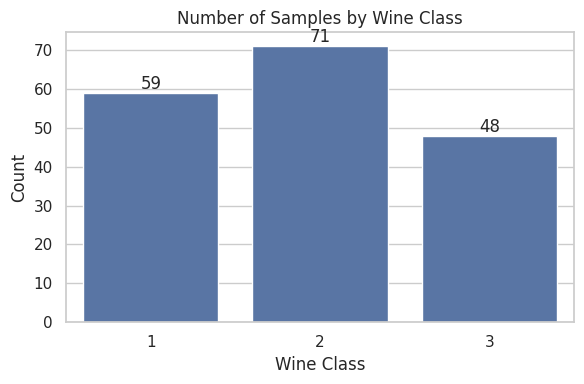

In [8]:
plt.figure(figsize=(6, 4))

ax = sns.countplot(data=df, x=target_col, order=sorted(df[target_col].unique()))

for container in ax.containers:
    ax.bar_label(container)

plt.title("Number of Samples by Wine Class")
plt.xlabel("Wine Class")
plt.ylabel("Count")

plt.tight_layout()
plt.show()

→ 1번 59개, 2번 71개, 3번 48개로 붓꽃(50/50/50)과 달리 **약간의 불균형**이 있습니다. 심각한 수준은 아니지만, 모델 평가 시 정확도 외에 클래스별 지표도 함께 보는 것이 좋습니다.

## 7. 기술통계량 확인

변수마다 단위와 크기가 매우 다릅니다. (예: `Hue`는 1 근처, `Proline`은 수백~천 단위)
이 점은 이후 KNN, SVM 같은 거리 기반 모델에서 **스케일링이 필요하다**는 것을 의미합니다.

In [9]:
display(df[numeric_cols].describe().round(3).T)

,count,mean,std,min,25%,50%,75%,max
Alcohol,178.0,13.001,0.812,11.03,12.362,13.050,13.678,14.83
Malic.acid,178.0,2.336,1.117,0.74,1.602,1.865,3.082,5.80
Ash,178.0,2.367,0.274,1.36,2.210,2.360,2.558,3.23
Acl,178.0,19.495,3.340,10.60,17.200,19.500,21.500,30.00
Mg,178.0,99.742,14.282,70.00,88.000,98.000,107.000,162.00
Phenols,178.0,2.295,0.626,0.98,1.742,2.355,2.800,3.88
Flavanoids,178.0,2.029,0.999,0.34,1.205,2.135,2.875,5.08
Nonflavanoid.phenols,178.0,0.362,0.124,0.13,0.270,0.340,0.438,0.66
Proanth,178.0,1.591,0.572,0.41,1.250,1.555,1.950,3.58
Color.int,178.0,5.058,2.318,1.28,3.220,4.690,6.200,13.00


## 8. 품종별 평균과 표준편차 확인

In [10]:
print("품종별 평균")
display(df.groupby(target_col)[numeric_cols].mean().round(3).T)

print("품종별 표준편차")
display(df.groupby(target_col)[numeric_cols].std().round(3).T)

품종별 평균


Wine,1,2,3
Alcohol,13.745,12.279,13.154
Malic.acid,2.011,1.933,3.334
Ash,2.456,2.245,2.437
Acl,17.037,20.238,21.417
Mg,106.339,94.549,99.312
Phenols,2.840,2.259,1.679
Flavanoids,2.982,2.081,0.781
Nonflavanoid.phenols,0.290,0.364,0.448
Proanth,1.899,1.630,1.154
Color.int,5.528,3.087,7.396


품종별 표준편차


Wine,1,2,3
Alcohol,0.462,0.538,0.530
Malic.acid,0.689,1.016,1.088
Ash,0.227,0.315,0.185
Acl,2.546,3.350,2.258
Mg,10.499,16.753,10.890
Phenols,0.339,0.545,0.357
Flavanoids,0.397,0.706,0.294
Nonflavanoid.phenols,0.070,0.124,0.124
Proanth,0.412,0.602,0.409
Color.int,1.239,0.925,2.311


## 9. 각 변수의 전체 분포 확인

13개 변수의 히스토그램을 한 화면에 그려 분포 모양(대칭, 치우침, 봉우리 개수)을 확인합니다.

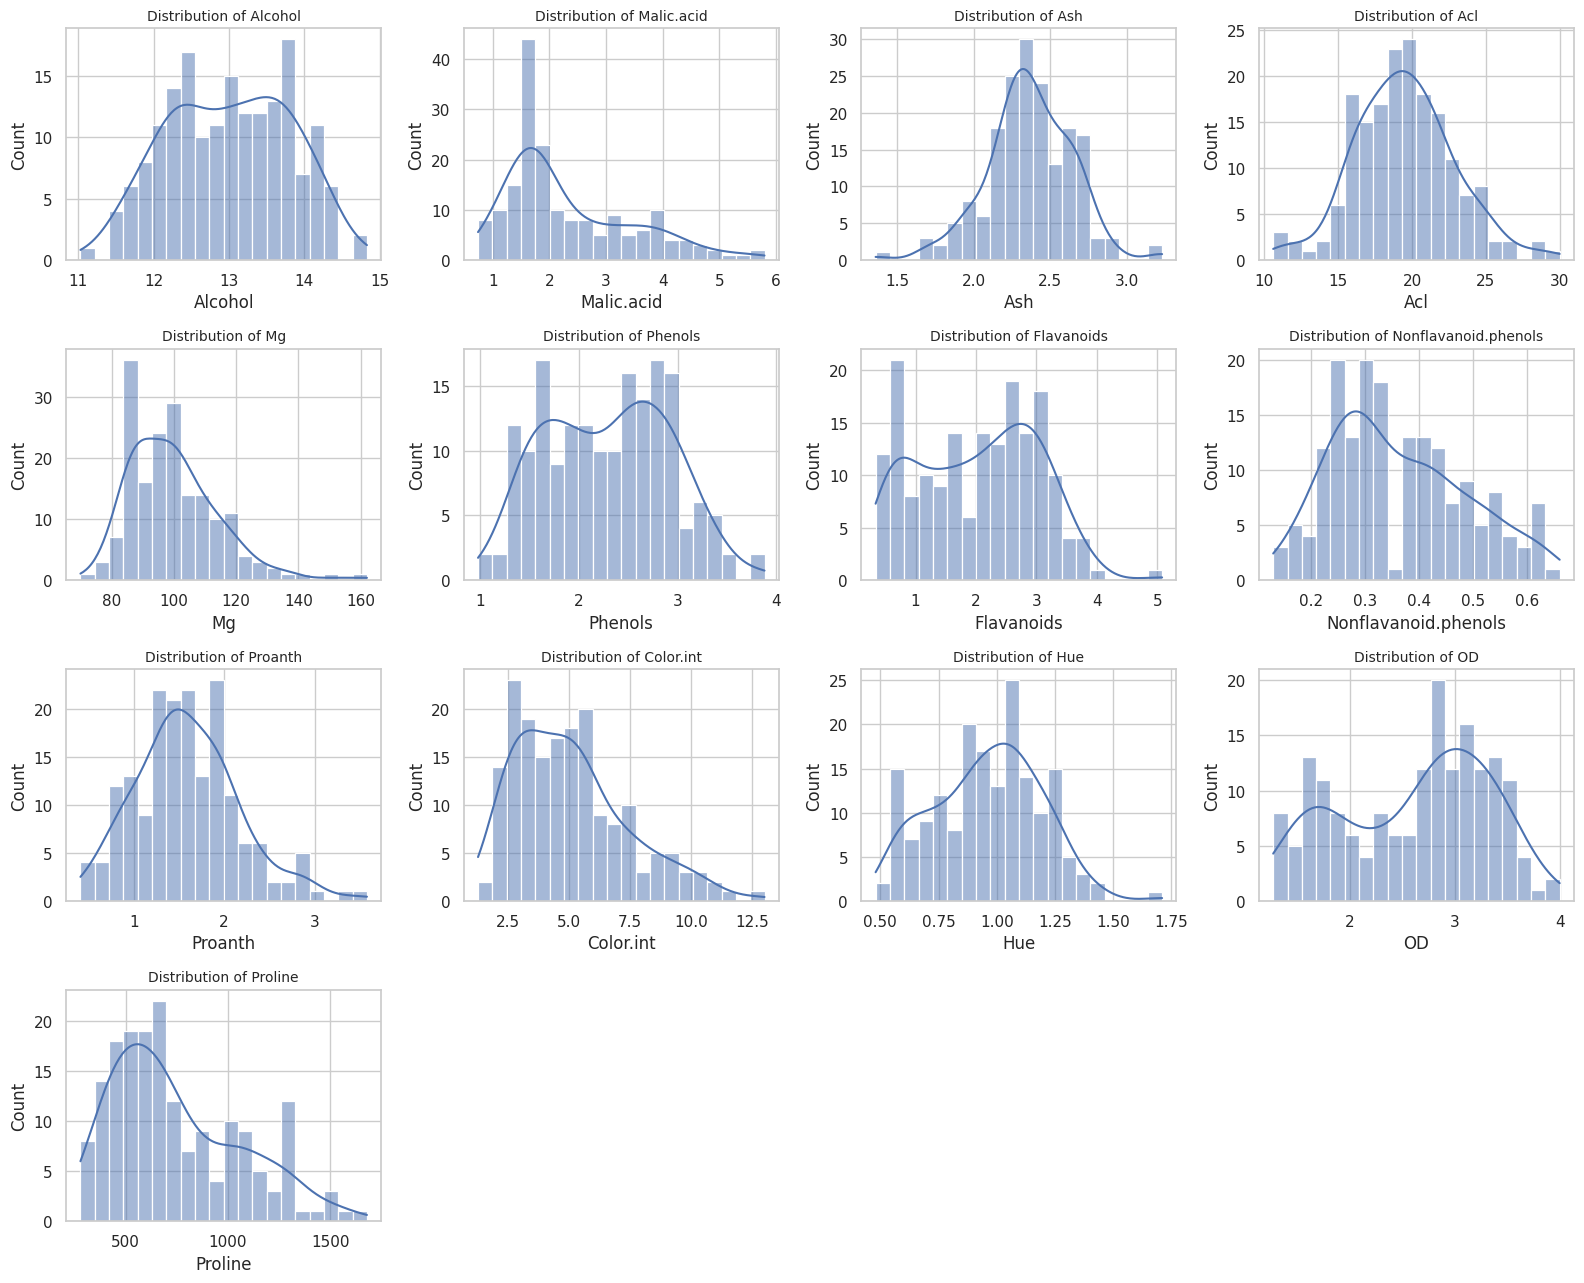

왜도(Skewness) - 절댓값이 클수록 한쪽으로 치우친 분포
Mg                      1.10
Malic.acid              1.04
Color.int               0.87
Proline                 0.77
Proanth                 0.52
Nonflavanoid.phenols    0.45
Acl                     0.21
Phenols                 0.09
Flavanoids              0.03
Hue                     0.02
Alcohol                -0.05
Ash                    -0.18
OD                     -0.31
dtype: float64


In [11]:
fig, axes = plt.subplots(4, 4, figsize=(16, 13))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    sns.histplot(data=df, x=col, bins=20, kde=True, ax=axes[i])
    axes[i].set_title(f"Distribution of {col}", fontsize=10)

for j in range(len(numeric_cols), len(axes)):
    axes[j].axis('off')

plt.tight_layout()
plt.show()

print("왜도(Skewness) - 절댓값이 클수록 한쪽으로 치우친 분포")
print(df[numeric_cols].skew().round(2).sort_values(ascending=False))

## 10. 품종별 변수 분포 비교

품종별 분포가 서로 떨어져 있을수록 해당 변수는 품종 구분에 유용합니다.

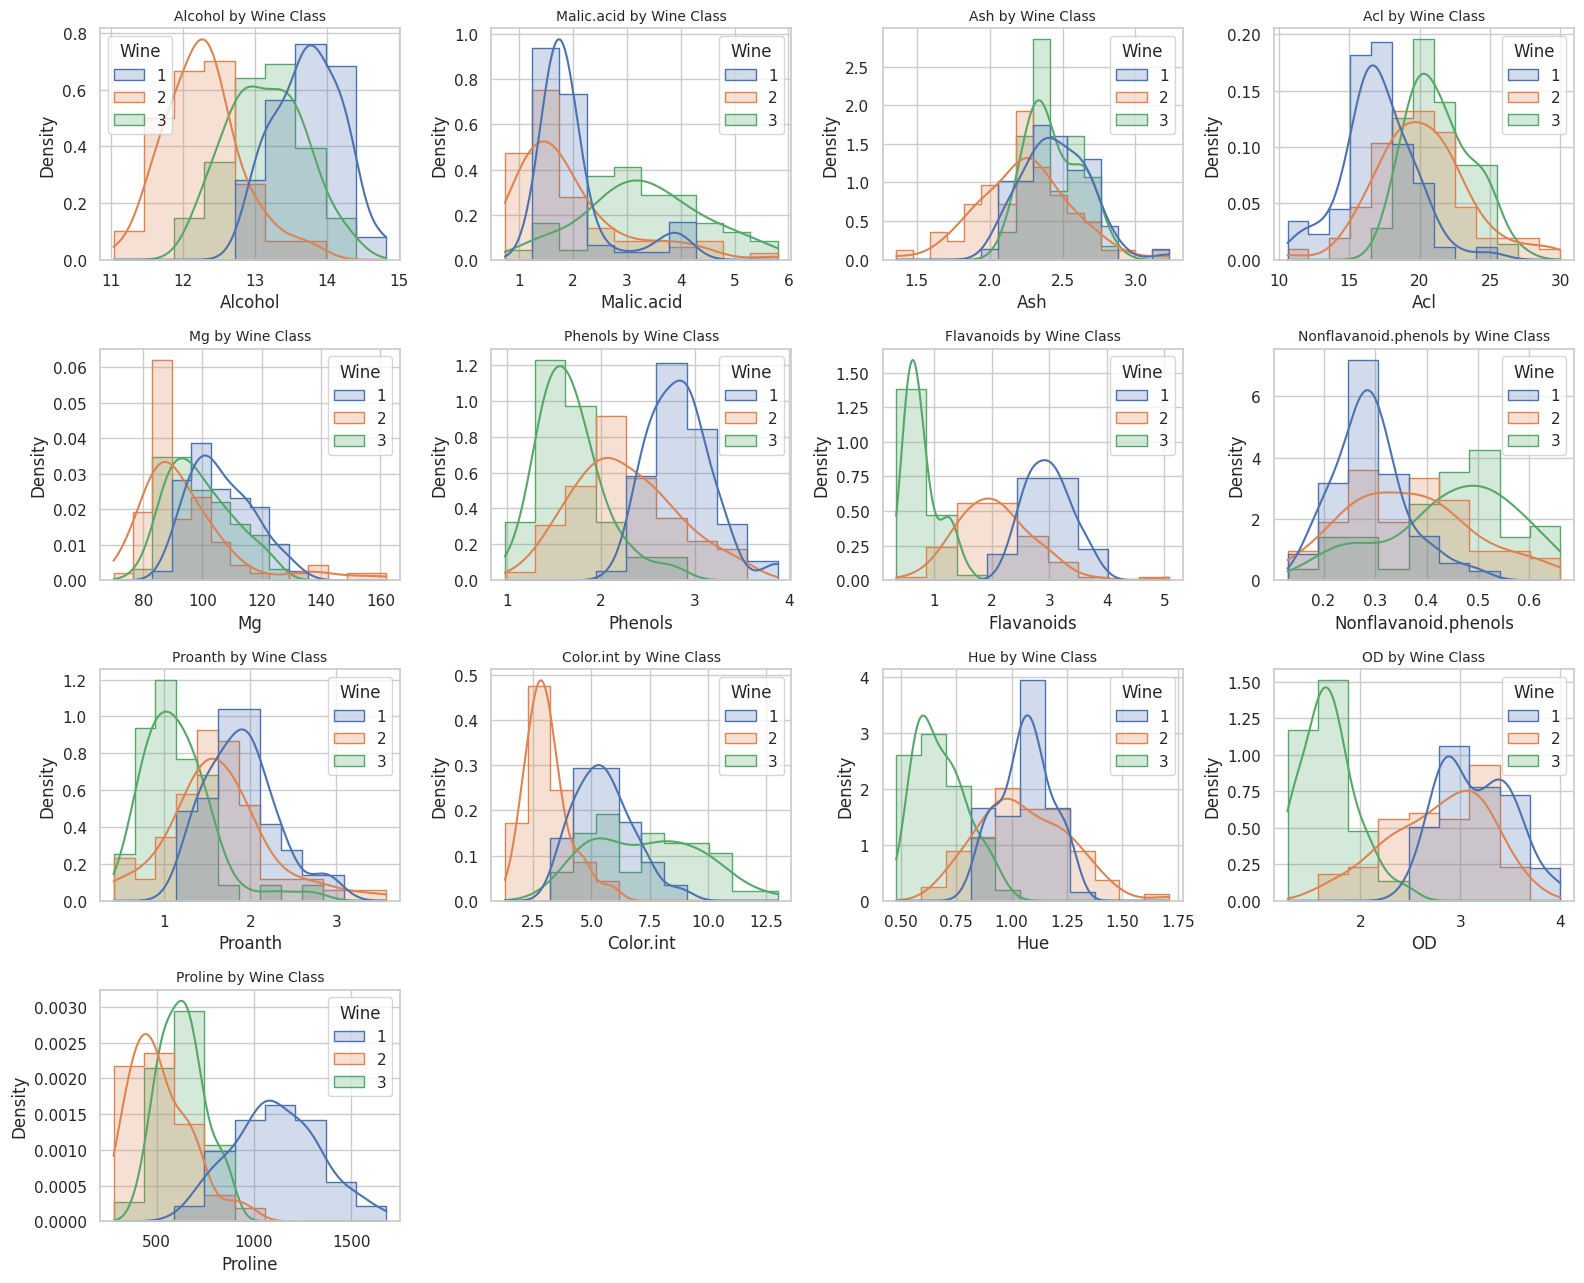

In [12]:
fig, axes = plt.subplots(4, 4, figsize=(16, 13))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    sns.histplot(data=df, x=col, hue=target_col, kde=True, element="step",
                 stat="density", common_norm=False, ax=axes[i],
                 hue_order=sorted(df[target_col].unique()))
    axes[i].set_title(f"{col} by Wine Class", fontsize=10)

for j in range(len(numeric_cols), len(axes)):
    axes[j].axis('off')

plt.tight_layout()
plt.show()

## 11. Box Plot

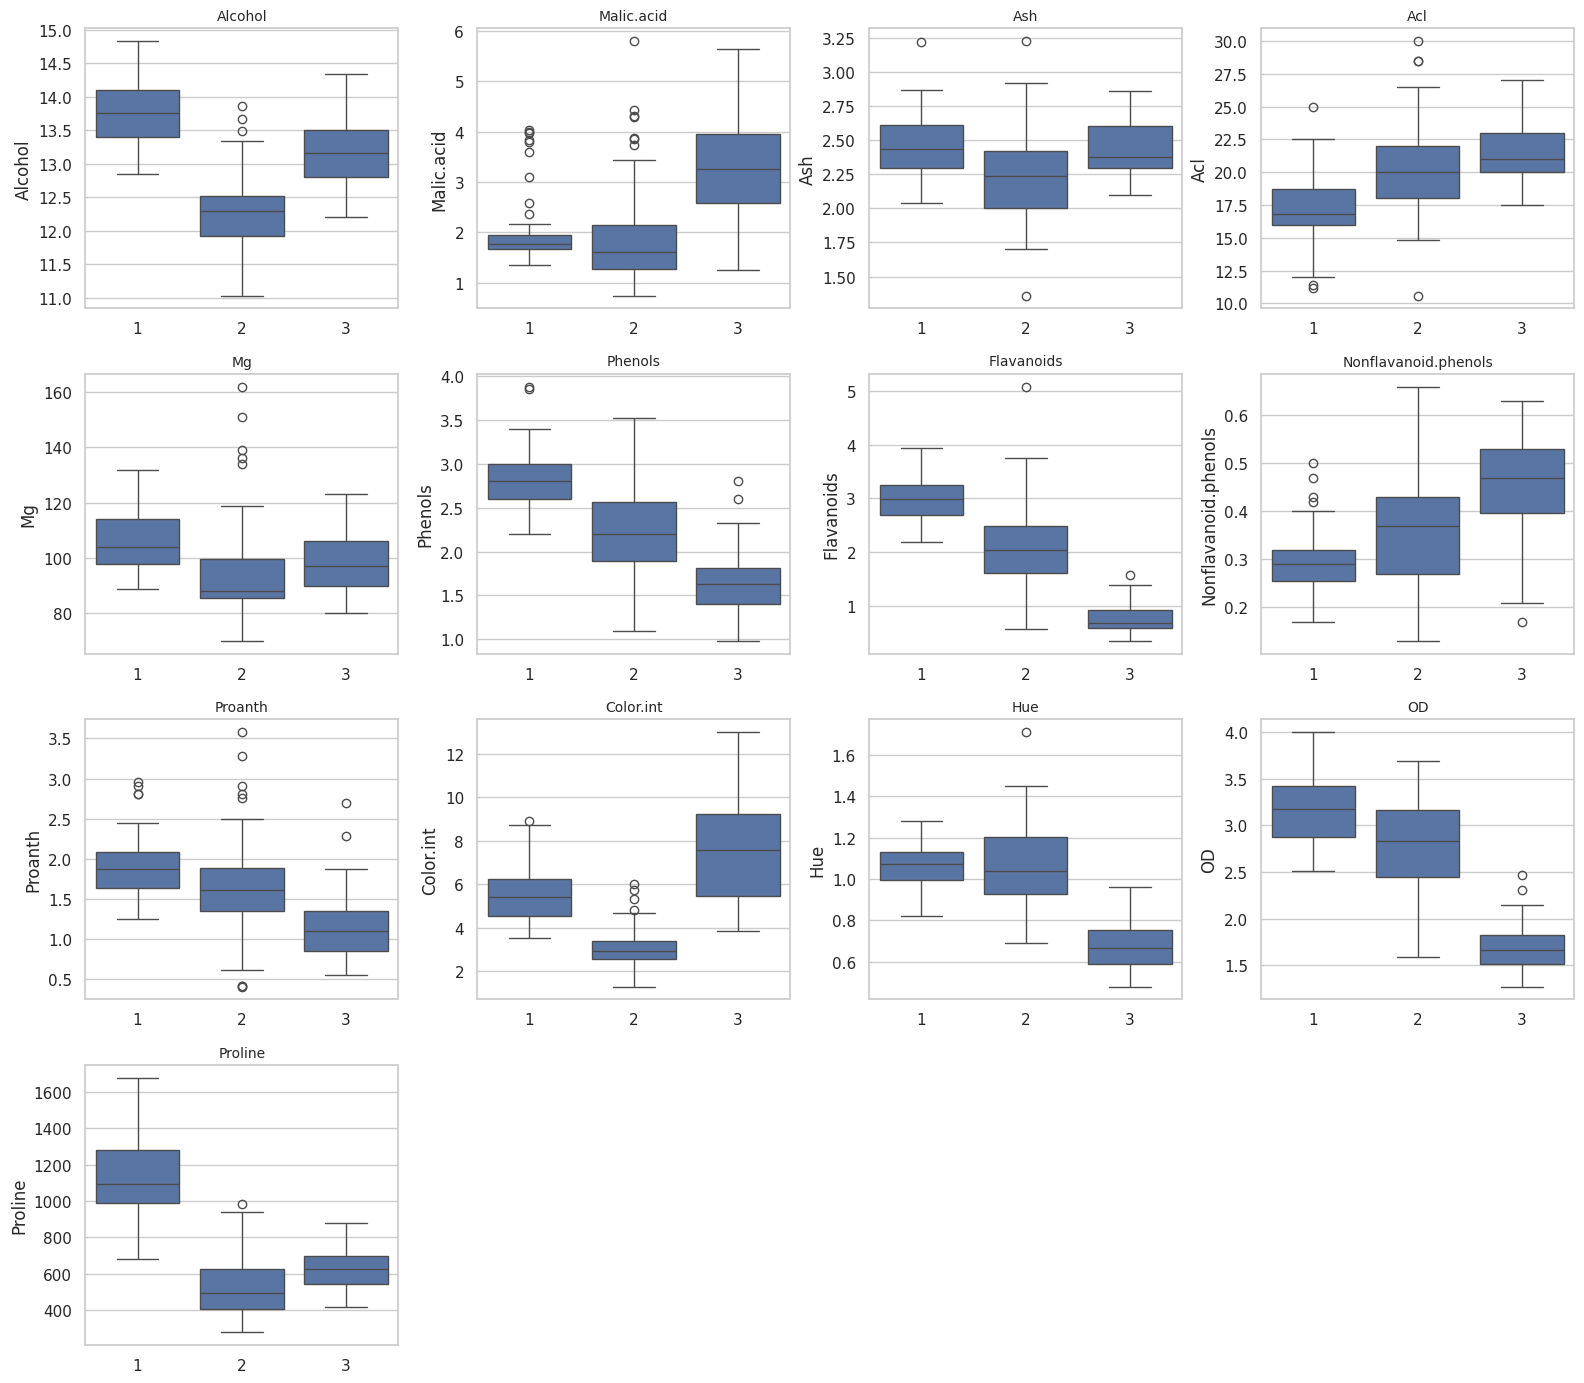

In [13]:
order = sorted(df[target_col].unique())

fig, axes = plt.subplots(4, 4, figsize=(16, 14))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    sns.boxplot(data=df, x=target_col, y=col, order=order, ax=axes[i])
    axes[i].set_title(col, fontsize=10)
    axes[i].set_xlabel("")

for j in range(len(numeric_cols), len(axes)):
    axes[j].axis('off')

plt.tight_layout()
plt.show()

## 12. Violin Plot

핵심 변수 5개에 대해 밀도까지 함께 확인합니다.

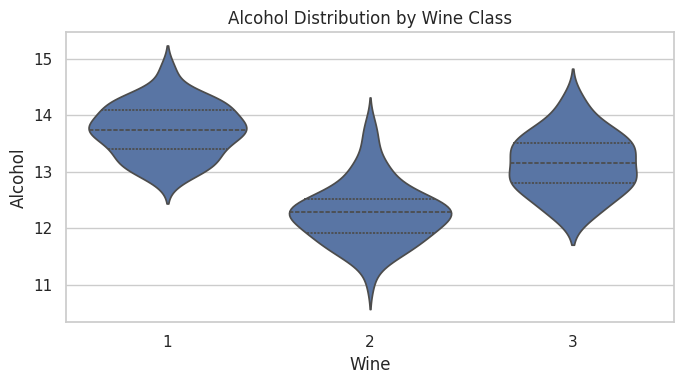

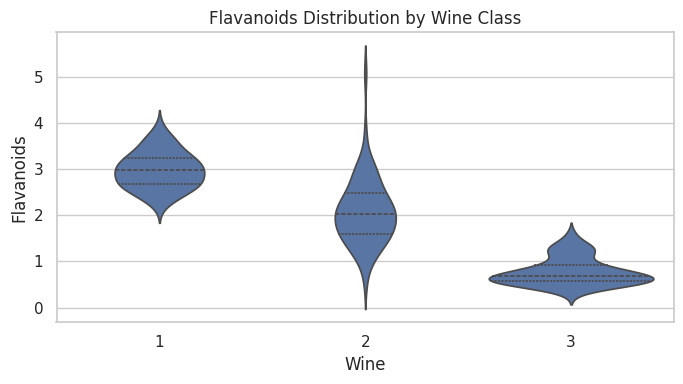

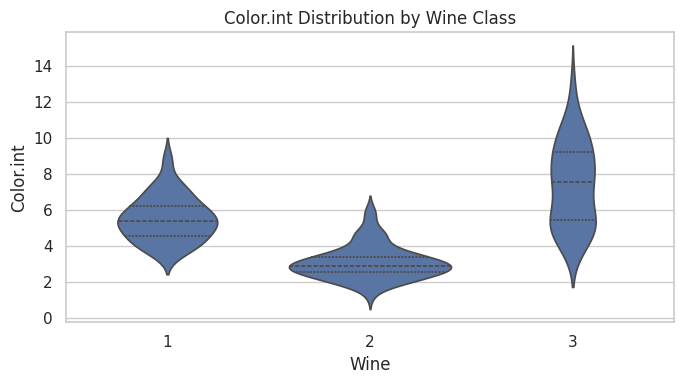

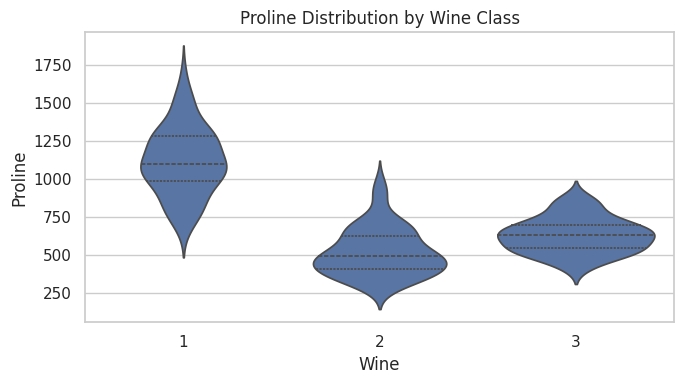

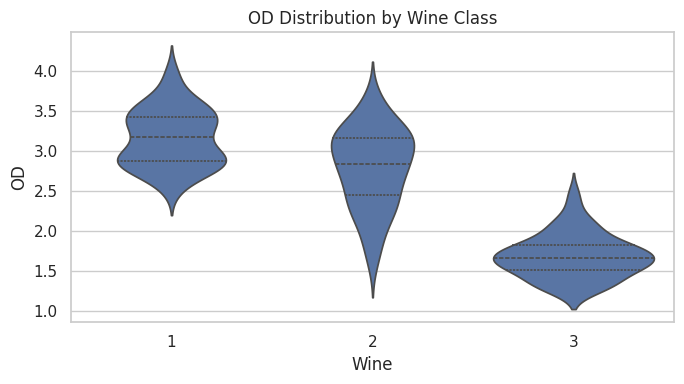

In [14]:
for col in key_cols:

    plt.figure(figsize=(7, 4))

    sns.violinplot(data=df, x=target_col, y=col, order=order, inner="quartile")

    plt.title(f"{col} Distribution by Wine Class")

    plt.tight_layout()
    plt.show()

## 13. Pair Plot

13개 변수를 모두 그리면 169개 그래프가 되어 읽기 어렵기 때문에 핵심 변수 5개만 사용합니다.

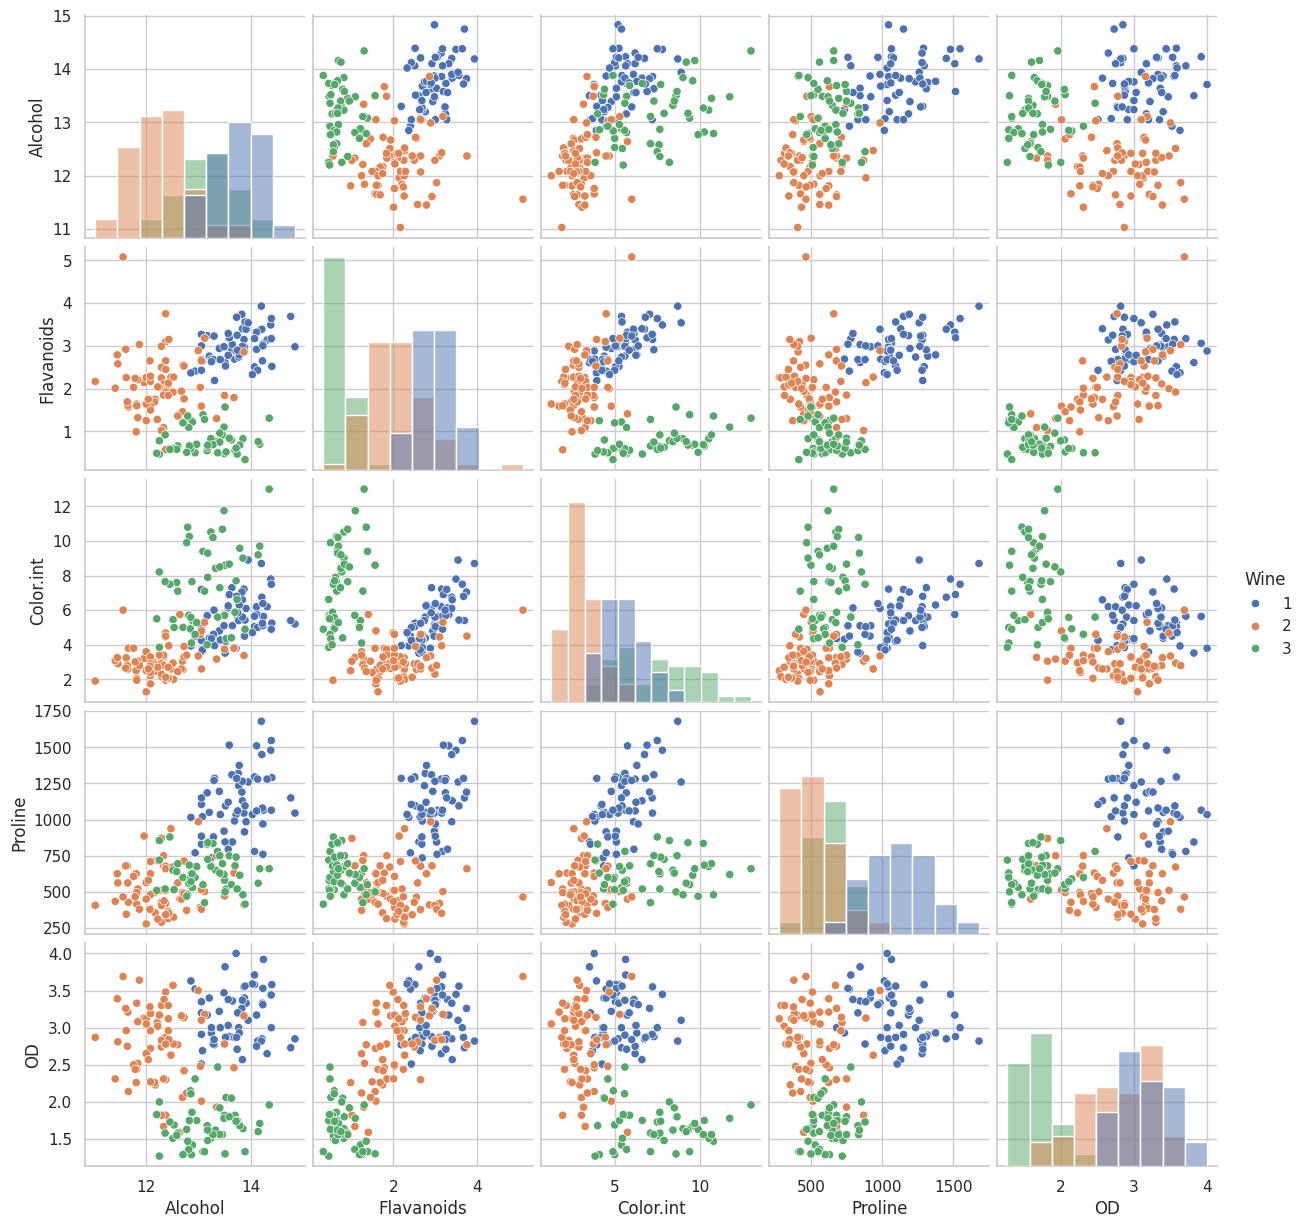

In [15]:
sns.pairplot(df, vars=key_cols, hue=target_col, hue_order=order, diag_kind="hist")

plt.show()

## 14. 변수 간 상관관계 분석

In [16]:
corr = df[numeric_cols].corr()

display(corr.round(3))

,Alcohol,Malic.acid,Ash,Acl,Mg,Phenols,Flavanoids,Nonflavanoid.phenols,Proanth,Color.int,Hue,OD,Proline
Alcohol,1.000,0.094,0.212,-0.310,0.271,0.289,0.237,-0.156,0.137,0.546,-0.072,0.072,0.644
Malic.acid,0.094,1.000,0.164,0.289,-0.055,-0.335,-0.411,0.293,-0.221,0.249,-0.561,-0.369,-0.192
Ash,0.212,0.164,1.000,0.443,0.287,0.129,0.115,0.186,0.010,0.259,-0.075,0.004,0.224
Acl,-0.310,0.289,0.443,1.000,-0.083,-0.321,-0.351,0.362,-0.197,0.019,-0.274,-0.277,-0.441
Mg,0.271,-0.055,0.287,-0.083,1.000,0.214,0.196,-0.256,0.236,0.200,0.055,0.066,0.393
Phenols,0.289,-0.335,0.129,-0.321,0.214,1.000,0.865,-0.450,0.612,-0.055,0.434,0.700,0.498
Flavanoids,0.237,-0.411,0.115,-0.351,0.196,0.865,1.000,-0.538,0.653,-0.172,0.543,0.787,0.494
Nonflavanoid.phenols,-0.156,0.293,0.186,0.362,-0.256,-0.450,-0.538,1.000,-0.366,0.139,-0.263,-0.503,-0.311
Proanth,0.137,-0.221,0.010,-0.197,0.236,0.612,0.653,-0.366,1.000,-0.025,0.296,0.519,0.330
Color.int,0.546,0.249,0.259,0.019,0.200,-0.055,-0.172,0.139,-0.025,1.000,-0.522,-0.429,0.316


### 상관관계 Heatmap

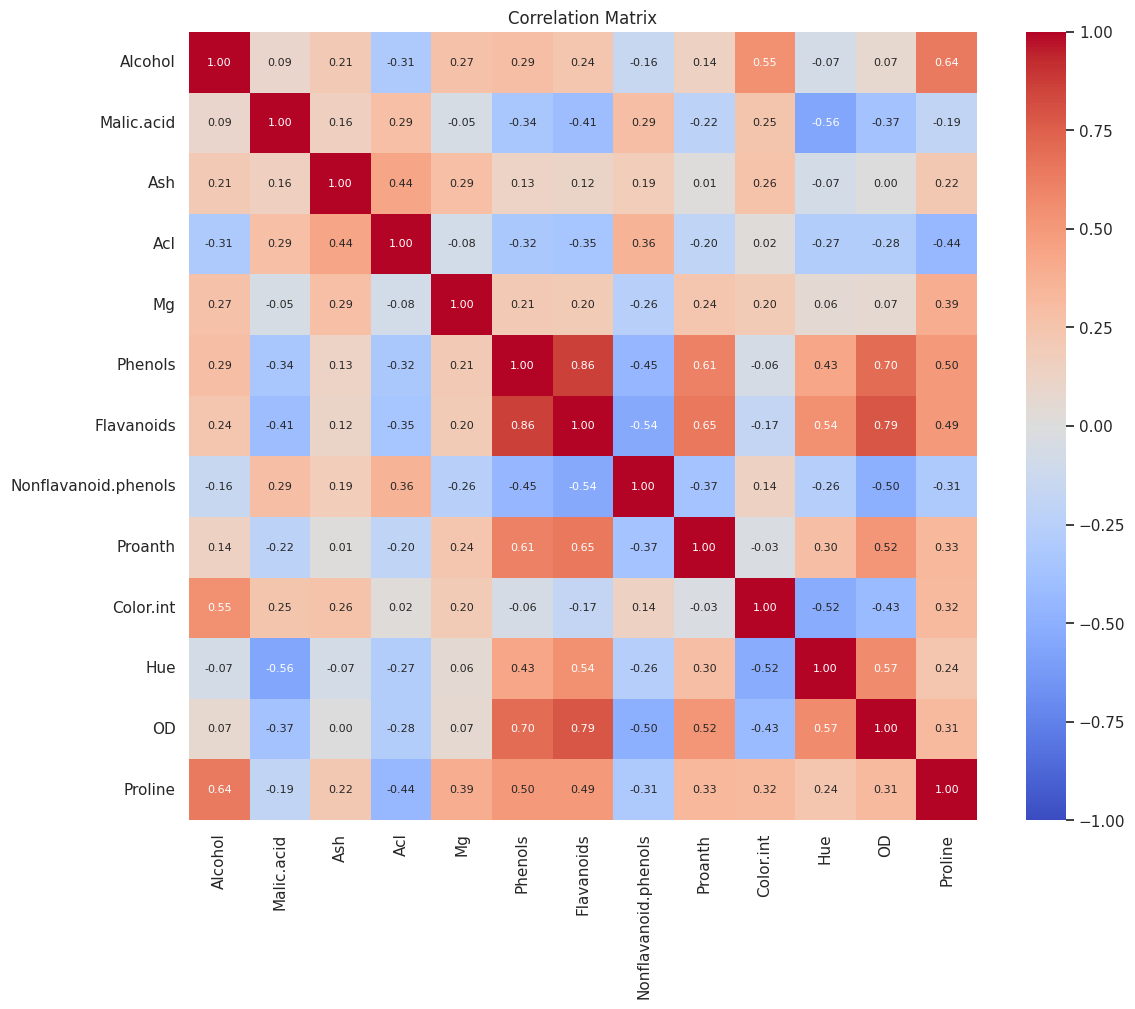

In [17]:
plt.figure(figsize=(12, 10))

sns.heatmap(corr, annot=True, fmt=".2f", square=True, cmap="coolwarm",
            vmin=-1, vmax=1, annot_kws={"size": 8})

plt.title("Correlation Matrix")

plt.tight_layout()
plt.show()

### 상관관계가 강한 변수 쌍

|r| ≥ 0.6 인 변수 쌍을 정리합니다. 강하게 상관된 변수들은 비슷한 정보를 담고 있으므로 다중공선성이나 차원 축소(PCA)를 고려할 수 있습니다.

In [18]:
pairs = (
    corr.where(np.triu(np.ones(corr.shape, dtype=bool), k=1))
        .stack()
        .reset_index()
)
pairs.columns = ['Feature 1', 'Feature 2', 'Correlation']
pairs['|r|'] = pairs['Correlation'].abs()

display(pairs[pairs['|r|'] >= 0.6].sort_values('|r|', ascending=False).round(3).reset_index(drop=True))

,Feature 1,Feature 2,Correlation,|r|
0,Phenols,Flavanoids,0.865,0.865
1,Flavanoids,OD,0.787,0.787
2,Phenols,OD,0.700,0.700
3,Flavanoids,Proanth,0.653,0.653
4,Alcohol,Proline,0.644,0.644
5,Phenols,Proanth,0.612,0.612


## 15. 플라보노이드와 프롤린의 관계

붓꽃의 꽃잎 길이/너비처럼, 와인에서는 `Flavanoids`와 `Proline` 조합에서 품종별 군집이 뚜렷하게 나타납니다.

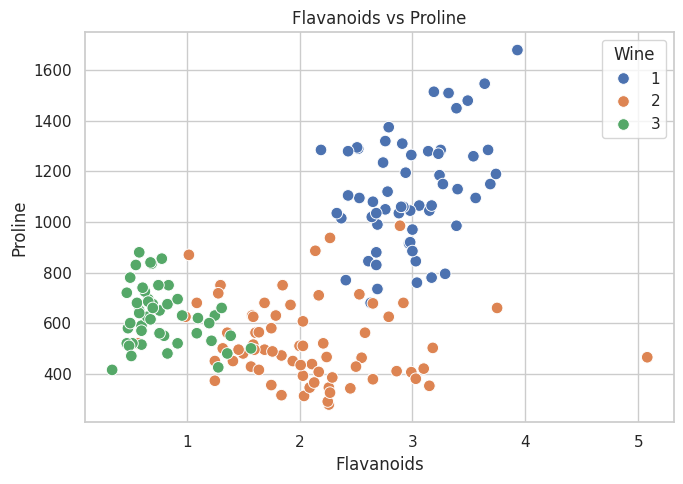

In [19]:
plt.figure(figsize=(7, 5))

sns.scatterplot(data=df, x='Flavanoids', y='Proline', hue=target_col, hue_order=order, s=70)

plt.title("Flavanoids vs Proline")
plt.xlabel("Flavanoids")
plt.ylabel("Proline")

plt.tight_layout()
plt.show()

## 16. 알코올과 색 강도의 관계

비교를 위해 `Alcohol`과 `Color.int`의 관계도 확인합니다. 이 조합은 2번(낮은 알코올, 연한 색)을 잘 구분하지만 1번과 3번은 일부 겹칩니다.

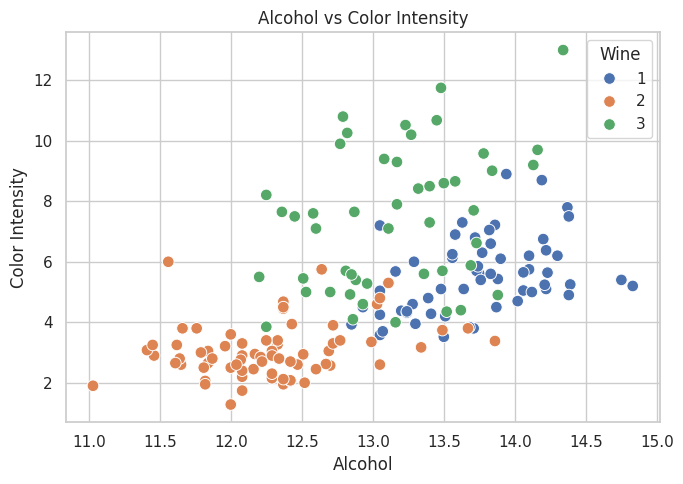

In [20]:
plt.figure(figsize=(7, 5))

sns.scatterplot(data=df, x='Alcohol', y='Color.int', hue=target_col, hue_order=order, s=70)

plt.title("Alcohol vs Color Intensity")
plt.xlabel("Alcohol")
plt.ylabel("Color Intensity")

plt.tight_layout()
plt.show()

## 17. IQR을 이용한 이상치 탐지

- `IQR = Q3 - Q1`
- 하한: `Q1 - 1.5 × IQR`, 상한: `Q3 + 1.5 × IQR`

이상치 후보라고 해서 바로 삭제하지 않고, 실제 오류인지 정상적인 극단값인지 확인이 필요합니다.

In [21]:
outlier_summary = []

for col in numeric_cols:

    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outliers = df[(df[col] < lower) | (df[col] > upper)]

    outlier_summary.append([col, len(outliers), round(lower, 2), round(upper, 2)])

    print(f"{col:30s} : {len(outliers)}개 (Lower={lower:.2f}, Upper={upper:.2f})")

Alcohol                        : 0개 (Lower=10.39, Upper=15.65)
Malic.acid                     : 3개 (Lower=-0.62, Upper=5.30)
Ash                            : 3개 (Lower=1.69, Upper=3.08)
Acl                            : 4개 (Lower=10.75, Upper=27.95)
Mg                             : 4개 (Lower=59.50, Upper=135.50)
Phenols                        : 0개 (Lower=0.16, Upper=4.39)
Flavanoids                     : 0개 (Lower=-1.30, Upper=5.38)
Nonflavanoid.phenols           : 0개 (Lower=0.02, Upper=0.69)
Proanth                        : 2개 (Lower=0.20, Upper=3.00)
Color.int                      : 4개 (Lower=-1.25, Upper=10.67)
Hue                            : 1개 (Lower=0.28, Upper=1.63)
OD                             : 0개 (Lower=0.09, Upper=5.02)
Proline                        : 0개 (Lower=-226.25, Upper=1711.75)


### 실제 이상치 데이터 확인

In [22]:
for col in numeric_cols:

    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outliers = df[(df[col] < lower) | (df[col] > upper)]

    if len(outliers) > 0:
        print(f"\n[{col} 이상치]")
        display(outliers[[col, target_col]])


[Malic.acid 이상치]


,Malic.acid,Wine
123,5.80,2
137,5.51,3
173,5.65,3



[Ash 이상치]


,Ash,Wine
25,3.22,1
59,1.36,2
121,3.23,2



[Acl 이상치]


...

,Proanth,Wine
95,3.28,2
110,3.58,2



[Color.int 이상치]


,Color.int,Wine
151,10.80,3
158,13.00,3
159,11.75,3
166,10.68,3



[Hue 이상치]


,Hue,Wine
115,1.71,2


## 18. 품종별 평균값 비교

붓꽃과 달리 와인 변수는 단위 차이가 매우 커서(`Proline` ≈ 750, `Hue` ≈ 1) 그대로 막대그래프를 그리면 `Proline`만 보입니다.
그래서 **표준화(Z-score)** 후 품종별 평균을 비교합니다. 0보다 크면 전체 평균보다 높고, 0보다 작으면 낮다는 뜻입니다.

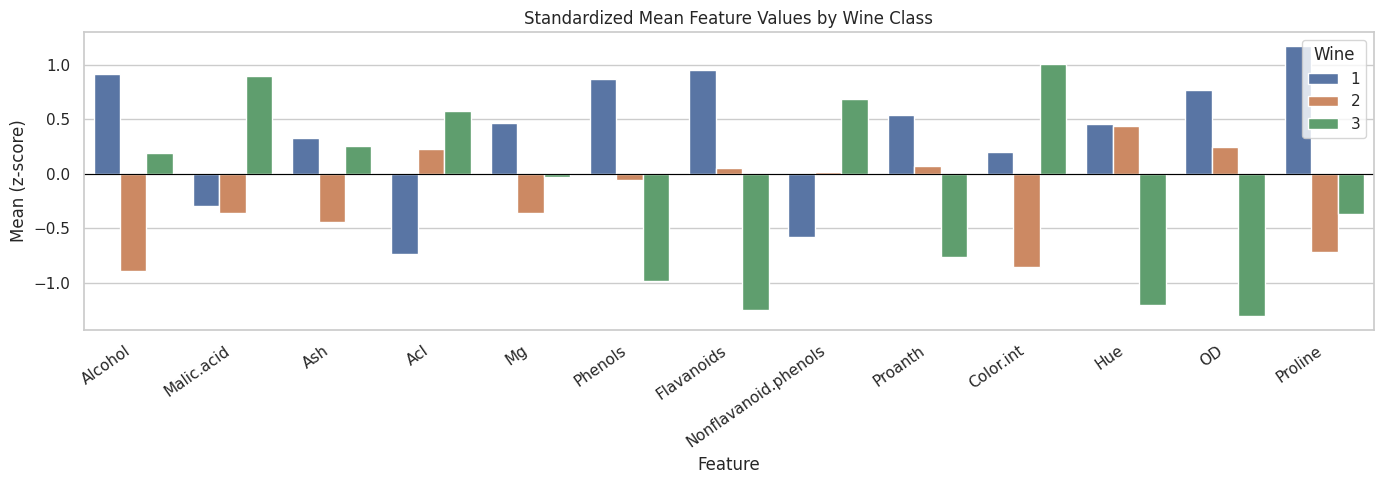

In [23]:
df_z = df.copy()
df_z[numeric_cols] = (df[numeric_cols] - df[numeric_cols].mean()) / df[numeric_cols].std()

mean_long = (
    df_z.groupby(target_col)[numeric_cols]
        .mean()
        .reset_index()
        .melt(id_vars=target_col, var_name="Feature", value_name="Mean (z-score)")
)

plt.figure(figsize=(14, 5))

sns.barplot(data=mean_long, x="Feature", y="Mean (z-score)", hue=target_col, hue_order=order)

plt.axhline(0, color='black', linewidth=0.8)
plt.title("Standardized Mean Feature Values by Wine Class")
plt.xticks(rotation=35, ha='right')

plt.tight_layout()
plt.show()

## 19. 변동계수(CV) 확인

변동계수 = 표준편차 / 평균. 단위가 다른 변수들의 **상대적인 흩어짐 정도**를 비교할 수 있습니다.

,CV
Flavanoids,0.492
Malic.acid,0.478
Color.int,0.458
Proline,0.422
Proanth,0.360
Nonflavanoid.phenols,0.344
Phenols,0.273
OD,0.272
Hue,0.239
Acl,0.171


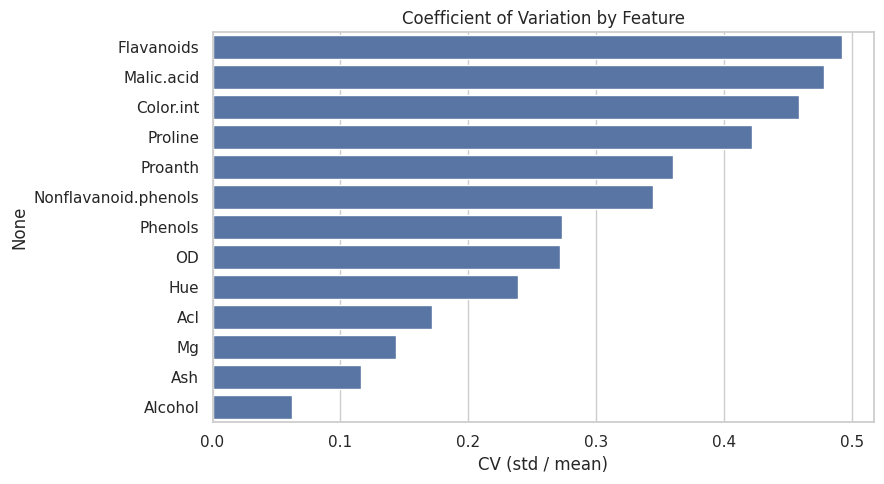

In [24]:
cv = (df[numeric_cols].std() / df[numeric_cols].mean()).sort_values(ascending=False)

display(cv.round(3).to_frame('CV'))

plt.figure(figsize=(9, 5))
sns.barplot(x=cv.values, y=cv.index)
plt.title("Coefficient of Variation by Feature")
plt.xlabel("CV (std / mean)")
plt.tight_layout()
plt.show()

## 20. 변수별 품종 분리도 확인 (ANOVA F값)

일원분산분석(ANOVA)의 F값은 **(품종 간 차이) / (품종 내 흩어짐)** 입니다.
F값이 클수록 그 변수 하나만으로도 품종을 잘 구별할 수 있다는 의미입니다.

,Feature,F,p-value
0,Flavanoids,233.9259,0.0
1,Proline,207.9204,0.0
2,OD,189.9723,0.0
3,Alcohol,135.0776,0.0
4,Color.int,120.6640,0.0
5,Hue,101.3168,0.0
6,Phenols,93.7330,0.0
7,Malic.acid,36.9434,0.0
8,Acl,35.7716,0.0
9,Proanth,30.2714,0.0


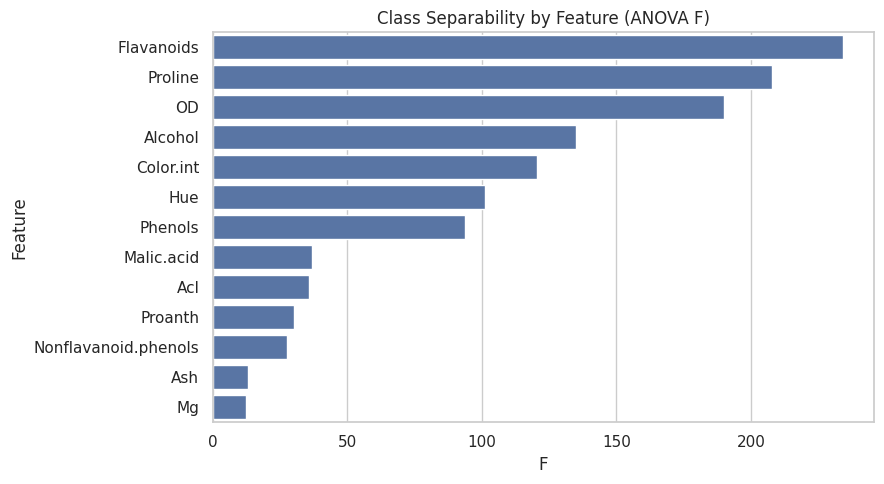

In [25]:
from scipy.stats import f_oneway

sep = []
for col in numeric_cols:
    groups = [g[col].values for _, g in df.groupby(target_col)]
    F, p = f_oneway(*groups)
    sep.append([col, F, p])

sep_df = pd.DataFrame(sep, columns=['Feature', 'F', 'p-value']).sort_values('F', ascending=False)
display(sep_df.round(4).reset_index(drop=True))

plt.figure(figsize=(9, 5))
sns.barplot(data=sep_df, x='F', y='Feature')
plt.title("Class Separability by Feature (ANOVA F)")
plt.tight_layout()
plt.show()

## 21. EDA 결과 해석

**데이터 구조 확인 → 데이터 품질 확인 → 레이블 확인 → 기술통계 → 분포 확인 → 품종별 비교 → 변수 관계 확인 → 상관관계 → 이상치 → 중요한 변수 탐색**

와인 데이터에서 확인한 내용:

- **데이터 품질**: 178개 샘플, 13개 변수, 결측치와 중복 행이 없습니다.
- **클래스 분포**: 59 / 71 / 48로 약간 불균형합니다.
- **스케일 차이**: `Proline`(수백~천)과 `Hue`(1 근처)처럼 변수 크기 차이가 커서, 거리 기반 모델에서는 표준화가 필요합니다.
- **분리도가 높은 변수**: `Proline`, `Flavanoids`, `OD`, `Alcohol`, `Color.int`의 ANOVA F값이 큽니다.
  - 1번: 알코올·프롤린·플라보노이드가 모두 높음
  - 2번: 알코올과 색 강도가 낮음
  - 3번: 플라보노이드와 OD280/OD315가 낮고, 색 강도가 높음
- **상관관계**: `Phenols`–`Flavanoids`–`od280/od315` 사이의 상관이 강해(r ≈ 0.7~0.86) 비슷한 정보를 담고 있습니다.
- **이상치**: `Mg`, `Malic.acid`, `Color.int` 등에서 일부 이상치 후보가 있지만, 특정 품종의 정상적인 극단값일 수 있어 바로 삭제하지 않습니다.

붓꽃 데이터에서 꽃잎 변수 2개만으로 품종이 거의 구분되었던 것처럼, 와인 데이터에서도 `Flavanoids`와 `Proline` 두 변수의 산점도만으로 세 품종이 상당히 잘 분리됩니다.

이후 머신러닝을 위한 질문:

- 표준화 후 모델 성능은 얼마나 달라질까?
- 강하게 상관된 페놀 계열 변수 중 일부만 사용해도 성능이 유지될까?
- PCA로 13차원을 2~3차원으로 줄여도 품종이 구분될까?
- 약간의 클래스 불균형이 분류 성능에 영향을 줄까?